# CBG (Constraint-Based Geolocation) Tutorial

This notebook walks through the CBG algorithm step-by-step using the Vultr US ping dataset.

## What is CBG?

CBG uses **RTT (Round-Trip Time)** measurements from multiple **Vantage Points (VPs)** to estimate a target's location:

1. **Measure RTT** from multiple VPs to the target
2. **Convert RTT to distance** (light/signal travel time → kilometers)
3. **Draw circles** around each VP with radius = max possible distance
4. **Find intersection** of all circles
5. **Calculate centroid** of intersection region = estimated location

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import radians, cos, sin, asin, sqrt, pi
import itertools

# Load the dataset
df = pd.read_csv('../datasets/cbg_test/vultr_pings_us_only.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nUnique targets (anchors): {df['dst_ip'].nunique()}")
print(f"Unique VPs (probes): {df['src_ip'].nunique()}")

Dataset shape: (9866, 18)

Columns: ['src_ip', 'dst_ip', 'prb_id', 'min_rtt', 'mean_rtt', 'sent', 'rcvd', 'msm_id', 'date', 'probe_asn', 'probe_country', 'probe_latitude', 'probe_longitude', 'anchor_asn', 'anchor_country', 'anchor_latitude', 'anchor_longitude', 'anchor_city']

Unique targets (anchors): 7
Unique VPs (probes): 1423


In [2]:
# Show sample data
df.head(10)

,src_ip,dst_ip,prb_id,min_rtt,mean_rtt,sent,rcvd,msm_id,date,probe_asn,probe_country,probe_latitude,probe_longitude,anchor_asn,anchor_country,anchor_latitude,anchor_longitude,anchor_city
0,3.15.133.134,45.77.211.82,1003386,66.333597,66.430588,3,3,52924044,2023-05-01 17:58:53,16509.0,US,39.9605,-82.9985,20473,US,47.6095,-122.3415,NaN
1,4.8.13.234,45.77.211.82,13283,41.252526,53.332965,3,3,52924030,2023-05-01 17:58:05,3356.0,US,32.9885,-96.7085,20473,US,47.6095,-122.3415,NaN
2,5.42.203.1,45.77.211.82,1005129,59.474578,59.606030,3,3,52924047,2023-05-01 17:59:02,212238.0,US,40.7115,-74.0115,20473,US,47.6095,-122.3415,NaN
3,5.161.76.19,45.77.211.82,1000916,65.406653,65.487370,3,3,52924042,2023-05-01 17:58:45,213230.0,US,39.0405,-77.4925,20473,US,47.6095,-122.3415,NaN
4,8.41.72.157,45.77.211.82,50356,57.948292,58.079847,3,3,52924038,2023-05-01 17:58:31,31922.0,US,43.1605,-77.6105,20473,US,47.6095,-122.3415,NaN
5,12.0.1.55,45.77.211.82,11171,66.228750,66.264554,3,3,52924029,2023-05-01 17:57:59,7018.0,US,40.3975,-74.1395,20473,US,47.6095,-122.3415,NaN
6,12.45.41.239,45.77.211.82,1002392,52.423753,52.716215,3,3,52924044,2023-05-01 17:59:10,7018.0,US,43.4185,-88.7785,20473,US,47.6095,-122.3415,NaN
7,12.50.26.2,45.77.211.82,51193,31.430500,31.650833,3,3,52924038,2023-05-01 17:58:30,7018.0,US,33.6185,-117.6885,20473,US,47.6095,-122.3415,NaN
8,12.162.21.31,45.77.211.82,32567,49.542703,56.577981,3,3,52924037,2023-05-01 17:58:25,31978.0,US,35.1405,-120.5495,20473,US,47.6095,-122.3415,NaN
9,12.179.178.252,45.77.211.82,1002663,22.460714,22.494410,3,3,52924044,2023-05-01 17:58:53,17117.0,US,37.5485,-121.9895,20473,US,47.6095,-122.3415,NaN


---
## Step 1: Understanding the Data

Key columns:
- `src_ip`: VP (Vantage Point) IP - the probe doing the measurement
- `dst_ip`: Target IP - the anchor we want to geolocate
- `min_rtt`: Minimum RTT in milliseconds
- `probe_latitude`, `probe_longitude`: VP's known location
- `anchor_latitude`, `anchor_longitude`: Target's **true** location (ground truth for validation)

In [3]:
# Pick ONE target to geolocate
target_ip = '45.77.211.82'  # A Vultr anchor in Seattle

# Get all measurements to this target
target_data = df[df['dst_ip'] == target_ip].copy()
print(f"Measurements to target {target_ip}: {len(target_data)}")

# Ground truth location
true_lat = target_data['anchor_latitude'].iloc[0]
true_lon = target_data['anchor_longitude'].iloc[0]
print(f"\nTrue location: ({true_lat}, {true_lon})")
print(f"City: Seattle, WA (Vultr datacenter)")

Measurements to target 45.77.211.82: 1384

True location: (47.6095, -122.3415)
City: Seattle, WA (Vultr datacenter)


In [4]:
# Show the VPs measuring this target (sorted by RTT)
vp_data = target_data[['src_ip', 'min_rtt', 'probe_latitude', 'probe_longitude', 'probe_asn']].copy()
vp_data = vp_data.sort_values('min_rtt')
print(f"VPs sorted by RTT (lowest first):")
vp_data.head(20)

VPs sorted by RTT (lowest first):


,src_ip,min_rtt,probe_latitude,probe_longitude,probe_asn
1068,149.248.34.85,0.286563,47.6095,-122.3295,20473.0
177,45.63.36.22,0.343342,47.6075,-122.3385,20473.0
1061,147.28.0.36,0.441097,47.6105,-122.3425,3130.0
1320,208.67.216.91,0.548850,47.6075,-122.3415,36692.0
36,23.105.67.239,0.558610,47.4875,-122.2915,396190.0
1060,147.28.0.33,0.645860,47.6095,-122.3425,3130.0
1042,140.142.107.23,1.036639,47.6575,-122.3115,73.0
990,128.208.6.70,1.063205,47.6505,-122.3125,73.0
1062,147.28.0.132,1.228032,47.6075,-122.3385,3130.0
1300,205.175.118.126,1.597755,47.6505,-122.3125,73.0


---
## Step 2: Core Helper Functions

These are the building blocks of CBG.

In [5]:
def haversine(loc1, loc2):
    """
    Calculate the great-circle distance between two points on Earth.
    
    Args:
        loc1: (lat, lon) tuple in degrees
        loc2: (lat, lon) tuple in degrees
    
    Returns:
        Distance in kilometers
    """
    lat1, lon1 = loc1
    lat2, lon2 = loc2
    
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    # Earth's radius in km
    r = 6371
    return c * r

# Test it
seattle = (47.6095, -122.3415)
new_york = (40.7128, -74.0060)
print(f"Seattle to New York: {haversine(seattle, new_york):.1f} km")

Seattle to New York: 3866.2 km


In [8]:
# Million-scale paper uses a FIXED speed threshold of 2/3
# This is the speed of light in fiber optic cable (not vacuum)

SPEED_OF_LIGHT = 300  # km/ms (300,000 km/s)
SPEED_THRESHOLD = 2/3  # Fixed value used in million-scale paper

def rtt_to_km(rtt, speed_threshold=2/3):
    """
    Convert RTT (milliseconds) to maximum possible distance (km).
    
    Formula: distance = speed * time
    - RTT is round-trip, so one-way time = RTT / 2
    - Speed of light c = 300,000 km/s = 300 km/ms
    - Effective speed in fiber = c * 2/3 (million-scale paper uses fixed 2/3)
    
    distance = (2/3 * c) * (RTT / 2)
             = (2/3) * 300 * RTT / 2
             = 100 * RTT
    
    NOTE: The codebase has a variable speed function (1/6, 3/9, 4/9 based on RTT),
    but the million-scale paper ALWAYS passes speed_threshold=2/3, so that
    variable logic is never used in practice.
    """
    c = 300  # Speed of light in km/ms
    return speed_threshold * rtt * c / 2

# Example calculations
print("RTT to Distance Conversion (using fixed 2/3 speed threshold)")
print("="*60)
print(f"Speed of light: {SPEED_OF_LIGHT} km/ms")
print(f"Speed threshold: {SPEED_THRESHOLD} (2/3 of c, as used in million-scale paper)")
print(f"Effective speed: {SPEED_OF_LIGHT * SPEED_THRESHOLD:.1f} km/ms = 200,000 km/s")
print()

for rtt_example in [5, 20, 50, 100]:
    max_dist = rtt_to_km(rtt_example)
    print(f"RTT = {rtt_example:3} ms  →  Max distance = {max_dist:,.0f} km")

RTT to Distance Conversion (using fixed 2/3 speed threshold)
Speed of light: 300 km/ms
Speed threshold: 0.6666666666666666 (2/3 of c, as used in million-scale paper)
Effective speed: 200.0 km/ms = 200,000 km/s

RTT =   5 ms  →  Max distance = 500 km
RTT =  20 ms  →  Max distance = 2,000 km
RTT =  50 ms  →  Max distance = 5,000 km
RTT = 100 ms  →  Max distance = 10,000 km


In [9]:
# Let's verify with our data
# Take a few VPs and see if distances make sense

print("VP Location vs. Target Location Analysis:")
print("="*70)
print(f"Using fixed speed_threshold = 2/3 (as in million-scale paper)")
print()

for i, row in vp_data.head(5).iterrows():
    vp_loc = (row['probe_latitude'], row['probe_longitude'])
    target_loc = (true_lat, true_lon)
    
    actual_distance = haversine(vp_loc, target_loc)
    max_distance = rtt_to_km(row['min_rtt'], speed_threshold=2/3)
    
    status = "✓ OK" if max_distance >= actual_distance else "✗ IMPOSSIBLE"
    
    print(f"VP: {row['src_ip']}")
    print(f"  RTT: {row['min_rtt']:.2f} ms")
    print(f"  Actual distance: {actual_distance:.1f} km")
    print(f"  Max possible distance (RTT × 100): {max_distance:.1f} km")
    print(f"  Status: {status}")
    print()

VP Location vs. Target Location Analysis:
Using fixed speed_threshold = 2/3 (as in million-scale paper)

VP: 149.248.34.85
  RTT: 0.29 ms
  Actual distance: 0.9 km
  Max possible distance (RTT × 100): 28.7 km
  Status: ✓ OK

VP: 45.63.36.22
  RTT: 0.34 ms
  Actual distance: 0.3 km
  Max possible distance (RTT × 100): 34.3 km
  Status: ✓ OK

VP: 147.28.0.36
  RTT: 0.44 ms
  Actual distance: 0.1 km
  Max possible distance (RTT × 100): 44.1 km
  Status: ✓ OK

VP: 208.67.216.91
  RTT: 0.55 ms
  Actual distance: 0.2 km
  Max possible distance (RTT × 100): 54.9 km
  Status: ✓ OK

VP: 23.105.67.239
  RTT: 0.56 ms
  Actual distance: 14.1 km
  Max possible distance (RTT × 100): 55.9 km
  Status: ✓ OK



---
## Step 3: Create Circles from RTT Measurements

Each VP creates a **circle** constraint:
- **Center**: VP's location
- **Radius**: Maximum distance derived from RTT

The target MUST be inside all circles!

In [10]:
def is_within_circle(vp_geo, rtt, candidate_geo, speed_threshold=None):
    """
    Check if a candidate location is within the RTT-derived circle.
    
    Args:
        vp_geo: (lat, lon) of the VP (circle center)
        rtt: RTT measurement in ms
        candidate_geo: (lat, lon) to check
        speed_threshold: Optional fixed speed fraction
    
    Returns:
        True if candidate is within the circle
    """
    max_dist = rtt_to_km(rtt, speed_threshold)
    actual_dist = haversine(vp_geo, candidate_geo)
    return actual_dist <= max_dist

# Test: Is the true location within our circles?
print("Checking if true location is within each VP's circle:")
print("="*60)

for i, row in vp_data.head(10).iterrows():
    vp_loc = (row['probe_latitude'], row['probe_longitude'])
    target_loc = (true_lat, true_lon)
    
    within = is_within_circle(vp_loc, row['min_rtt'], target_loc, speed_threshold=2/3)
    status = "✓ Inside" if within else "✗ Outside"
    print(f"VP {row['src_ip'][:15]:15} RTT={row['min_rtt']:6.2f}ms: {status}")

Checking if true location is within each VP's circle:
VP 149.248.34.85   RTT=  0.29ms: ✓ Inside
VP 45.63.36.22     RTT=  0.34ms: ✓ Inside
VP 147.28.0.36     RTT=  0.44ms: ✓ Inside
VP 208.67.216.91   RTT=  0.55ms: ✓ Inside
VP 23.105.67.239   RTT=  0.56ms: ✓ Inside
VP 147.28.0.33     RTT=  0.65ms: ✓ Inside
VP 140.142.107.23  RTT=  1.04ms: ✓ Inside
VP 128.208.6.70    RTT=  1.06ms: ✓ Inside
VP 147.28.0.132    RTT=  1.23ms: ✓ Inside
VP 205.175.118.126 RTT=  1.60ms: ✓ Inside


In [11]:
# Build circle list for CBG
# Circle format: (lat, lon, rtt, distance, radius_in_radians)

def build_circles(measurements_df, n_vps=10, speed_threshold=2/3):
    """
    Build circle constraints from measurements.
    
    Args:
        measurements_df: DataFrame with VP measurements
        n_vps: Number of VPs to use (select lowest RTT)
        speed_threshold: Speed fraction for distance calculation
    
    Returns:
        List of circles: [(lat, lon, rtt, distance_km, radius_radians), ...]
    """
    circles = []
    
    # Sort by RTT and take top n_vps
    sorted_df = measurements_df.sort_values('min_rtt').head(n_vps)
    
    for _, row in sorted_df.iterrows():
        lat = row['probe_latitude']
        lon = row['probe_longitude']
        rtt = row['min_rtt']
        
        # Skip very high RTTs (likely inflated)
        if rtt > 100:
            continue
            
        d = rtt_to_km(rtt, speed_threshold)
        r = d / 6371  # Convert km to radians (Earth radius = 6371 km)
        
        circles.append((lat, lon, rtt, d, r))
    
    return circles

# Build circles from our data
circles = build_circles(target_data, n_vps=10, speed_threshold=2/3)

print(f"Created {len(circles)} circles:")
print("="*70)
print(f"{'#':3} {'Lat':>10} {'Lon':>10} {'RTT(ms)':>10} {'Dist(km)':>10}")
print("-"*70)
for i, (lat, lon, rtt, d, r) in enumerate(circles):
    print(f"{i+1:3} {lat:10.4f} {lon:10.4f} {rtt:10.2f} {d:10.1f}")

Created 10 circles:
#          Lat        Lon    RTT(ms)   Dist(km)
----------------------------------------------------------------------
  1    47.6095  -122.3295       0.29       28.7
  2    47.6075  -122.3385       0.34       34.3
  3    47.6105  -122.3425       0.44       44.1
  4    47.6075  -122.3415       0.55       54.9
  5    47.4875  -122.2915       0.56       55.9
  6    47.6095  -122.3425       0.65       64.6
  7    47.6575  -122.3115       1.04      103.7
  8    47.6505  -122.3125       1.06      106.3
  9    47.6075  -122.3385       1.23      122.8
 10    47.6505  -122.3125       1.60      159.8


---
## Step 4: Circle Preprocessing

Before finding intersections, we remove redundant circles:
- If circle A is completely inside circle B, we can ignore B
- The smaller circle already provides a tighter constraint

In [12]:
def check_circle_inclusion(c1, c2):
    """
    Check if one circle completely contains the other.
    
    Returns:
        (circle_to_remove, circle_to_keep) or (None, None) if no inclusion
    """
    lat1, lon1, rtt1, d1, r1 = c1
    lat2, lon2, rtt2, d2, r2 = c2
    
    # Distance between circle centers
    center_dist = haversine((lat1, lon1), (lat2, lon2))
    
    # Circle 1 contains Circle 2 if: d1 > center_dist + d2
    if d1 > (center_dist + d2):
        return c1, c2  # Remove c1 (larger), keep c2
    
    # Circle 2 contains Circle 1
    if d2 > (center_dist + d1):
        return c2, c1  # Remove c2 (larger), keep c1
    
    return None, None

def circle_preprocessing(circles):
    """
    Remove circles that are completely contained by others.
    
    The intersection of all circles is the same whether we include
    the containing circle or not, so we can simplify.
    """
    circles_to_ignore = set()
    
    for i in range(len(circles)):
        c1 = circles[i]
        if c1 in circles_to_ignore:
            continue
            
        for j in range(i + 1, len(circles)):
            c2 = circles[j]
            if c2 in circles_to_ignore:
                continue
                
            remove, keep = check_circle_inclusion(c1, c2)
            if remove:
                circles_to_ignore.add(remove)
    
    return [c for c in circles if c not in circles_to_ignore]

# Preprocess our circles
preprocessed = circle_preprocessing(circles)
print(f"Before preprocessing: {len(circles)} circles")
print(f"After preprocessing: {len(preprocessed)} circles")
print(f"Removed {len(circles) - len(preprocessed)} redundant circles")

Before preprocessing: 10 circles
After preprocessing: 1 circles
Removed 9 redundant circles


---
## Step 5: Find Circle Intersections

This is the **geometric heart** of CBG:

1. For each pair of circles, find their intersection points (0, 1, or 2 points)
2. Keep only points that lie inside ALL circles
3. These valid points define the feasible region

In [13]:
def geo_to_cartesian(lat, lon):
    """
    Convert geographic coordinates to 3D Cartesian (on unit sphere).
    """
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    
    x = np.cos(lon_rad) * np.cos(lat_rad)
    y = np.sin(lon_rad) * np.cos(lat_rad)
    z = np.sin(lat_rad)
    
    return np.array([x, y, z])

def find_two_circle_intersections(c1, c2):
    """
    Find intersection points of two circles on a sphere.
    
    Uses the spherical geometry formula from:
    https://gis.stackexchange.com/questions/48937/
    
    Returns:
        List of (lat, lon) intersection points (0, 1, or 2 points)
    """
    lat1, lon1, rtt1, d1, r1 = c1
    lat2, lon2, rtt2, d2, r2 = c2
    
    # Convert to Cartesian
    x1 = geo_to_cartesian(lat1, lon1)
    x2 = geo_to_cartesian(lat2, lon2)
    
    # Dot product (cosine of angle between centers)
    q = np.dot(x1, x2)
    
    # Handle numerical issues
    if abs(1 - q**2) < 1e-10:
        return []  # Circles are concentric or antipodal
    
    # Coefficients for the intersection plane
    a = (np.cos(r1) - np.cos(r2) * q) / (1 - q**2)
    b = (np.cos(r2) - np.cos(r1) * q) / (1 - q**2)
    
    # Point on the intersection line closest to origin
    x0 = a * x1 + b * x2
    
    # Normal to the plane containing both circle centers and Earth center
    n = np.cross(x1, x2)
    
    # Check if intersection exists
    discriminant = (1 - np.dot(x0, x0)) / np.dot(n, n)
    if discriminant <= 0:
        return []  # No intersection (circles don't overlap)
    
    t = np.sqrt(discriminant)
    
    # Two intersection points
    i1 = x0 + t * n
    i2 = x0 - t * n
    
    # Convert back to geographic coordinates
    points = []
    for pt in [i1, i2]:
        lon = np.degrees(np.arctan2(pt[1], pt[0]))
        lat = np.degrees(np.arctan(pt[2] / np.sqrt(pt[0]**2 + pt[1]**2)))
        points.append((lat, lon))
    
    return points

# Test with two of our circles
if len(preprocessed) >= 2:
    pts = find_two_circle_intersections(preprocessed[0], preprocessed[1])
    print(f"Intersection of circles 0 and 1: {len(pts)} points")
    for i, (lat, lon) in enumerate(pts):
        print(f"  Point {i+1}: ({lat:.4f}, {lon:.4f})")

In [14]:
def circle_intersections(circles, speed_threshold=2/3):
    """
    Find all valid intersection points from multiple circles.
    
    Steps:
    1. Preprocess to remove redundant circles
    2. Find all pairwise intersection points
    3. Filter: keep only points inside ALL circles
    
    Returns:
        (filtered_points, circles_used)
    """
    # Preprocess circles
    circles = circle_preprocessing(circles)
    
    # Special case: only one circle
    if len(circles) == 1:
        lat, lon, rtt, d, r = circles[0]
        # Return 4 points on the circle boundary
        points = []
        for angle in [0, 90, 180, 270]:
            rad = np.radians(angle)
            dx = d * np.cos(rad)
            dy = d * np.sin(rad)
            new_lat = lat + (180/pi) * (dy/6378137)
            new_lon = lon + (180/pi) * (dx/6378137) / np.cos(np.radians(lat))
            points.append((new_lat, new_lon))
        return points, circles
    
    # Find all pairwise intersections
    all_points = []
    for c1, c2 in itertools.combinations(circles, 2):
        pts = find_two_circle_intersections(c1, c2)
        all_points.extend(pts)
    
    print(f"Total intersection points from pairs: {len(all_points)}")
    
    # Filter: keep only points inside ALL circles
    valid_points = []
    for point in all_points:
        inside_all = True
        for lat_c, lon_c, rtt_c, d_c, r_c in circles:
            if not is_within_circle((lat_c, lon_c), rtt_c, point, speed_threshold):
                inside_all = False
                break
        if inside_all:
            valid_points.append(point)
    
    print(f"Points inside ALL circles: {len(valid_points)}")
    
    return valid_points, circles

# Find intersections
valid_points, used_circles = circle_intersections(circles, speed_threshold=2/3)

---
## Step 6: Calculate Centroid

The **centroid** of the valid intersection points is our location estimate.

In [15]:
def polygon_centroid(points):
    """
    Calculate the centroid of a set of points.
    
    Simple arithmetic mean of coordinates.
    For small regions on Earth, this is a good approximation.
    """
    if not points:
        return None
    
    lat_sum = sum(p[0] for p in points)
    lon_sum = sum(p[1] for p in points)
    n = len(points)
    
    return (lat_sum / n, lon_sum / n)

# Calculate centroid
if valid_points:
    estimated_location = polygon_centroid(valid_points)
    print(f"Estimated location: ({estimated_location[0]:.4f}, {estimated_location[1]:.4f})")
    print(f"True location:      ({true_lat:.4f}, {true_lon:.4f})")
    
    error = haversine(estimated_location, (true_lat, true_lon))
    print(f"\n*** GEOLOCATION ERROR: {error:.1f} km ***")
else:
    print("No valid intersection points found!")

Estimated location: (47.6095, -122.3295)
True location:      (47.6095, -122.3415)

*** GEOLOCATION ERROR: 0.9 km ***


---
## Step 7: Complete CBG Function

Let's wrap everything into a single function.

In [16]:
def cbg_geolocate(measurements_df, n_vps=10, speed_threshold=2/3, verbose=True):
    """
    Perform CBG geolocation on a target.
    
    Args:
        measurements_df: DataFrame with columns:
            - min_rtt: RTT measurement
            - probe_latitude, probe_longitude: VP location
        n_vps: Number of VPs to use (lowest RTT)
        speed_threshold: Speed fraction for distance calculation
        verbose: Print debug info
    
    Returns:
        (estimated_lat, estimated_lon) or None if geolocation fails
    """
    # Step 1: Build circles
    circles = build_circles(measurements_df, n_vps, speed_threshold)
    if verbose:
        print(f"Step 1: Built {len(circles)} circles from measurements")
    
    if not circles:
        if verbose:
            print("  ERROR: No valid circles!")
        return None
    
    # Step 2: Find intersections
    valid_points, used_circles = circle_intersections(circles, speed_threshold)
    if verbose:
        print(f"Step 2: Found {len(valid_points)} valid intersection points")
    
    # Step 3: Calculate centroid
    if len(valid_points) >= 3:
        centroid = polygon_centroid(valid_points)
        if verbose:
            print(f"Step 3: Centroid from {len(valid_points)} points")
    elif len(valid_points) == 2:
        # Midpoint of two points
        centroid = polygon_centroid(valid_points)
        if verbose:
            print(f"Step 3: Midpoint of 2 intersection points")
    else:
        # Fallback: use closest VP's location
        sorted_df = measurements_df.sort_values('min_rtt')
        row = sorted_df.iloc[0]
        centroid = (row['probe_latitude'], row['probe_longitude'])
        if verbose:
            print(f"Step 3: Fallback to closest VP location")
    
    return centroid, used_circles

# Test the complete function
print("="*60)
print("CBG GEOLOCATION TEST")
print("="*60)
print(f"Target: {target_ip}")
print(f"True location: ({true_lat}, {true_lon}) - Seattle, WA")
print()

result = cbg_geolocate(target_data, n_vps=10, speed_threshold=2/3, verbose=True)

if result:
    estimated, circles_used = result
    print()
    print(f"RESULT: Estimated location = ({estimated[0]:.4f}, {estimated[1]:.4f})")
    print(f"        True location      = ({true_lat:.4f}, {true_lon:.4f})")
    print(f"        Error = {haversine(estimated, (true_lat, true_lon)):.1f} km")

CBG GEOLOCATION TEST
Target: 45.77.211.82
True location: (47.6095, -122.3415) - Seattle, WA

Step 1: Built 10 circles from measurements
Step 2: Found 4 valid intersection points
Step 3: Centroid from 4 points

RESULT: Estimated location = (47.6095, -122.3295)
        True location      = (47.6095, -122.3415)
        Error = 0.9 km


---
## Step 8: Visualize the CBG Process

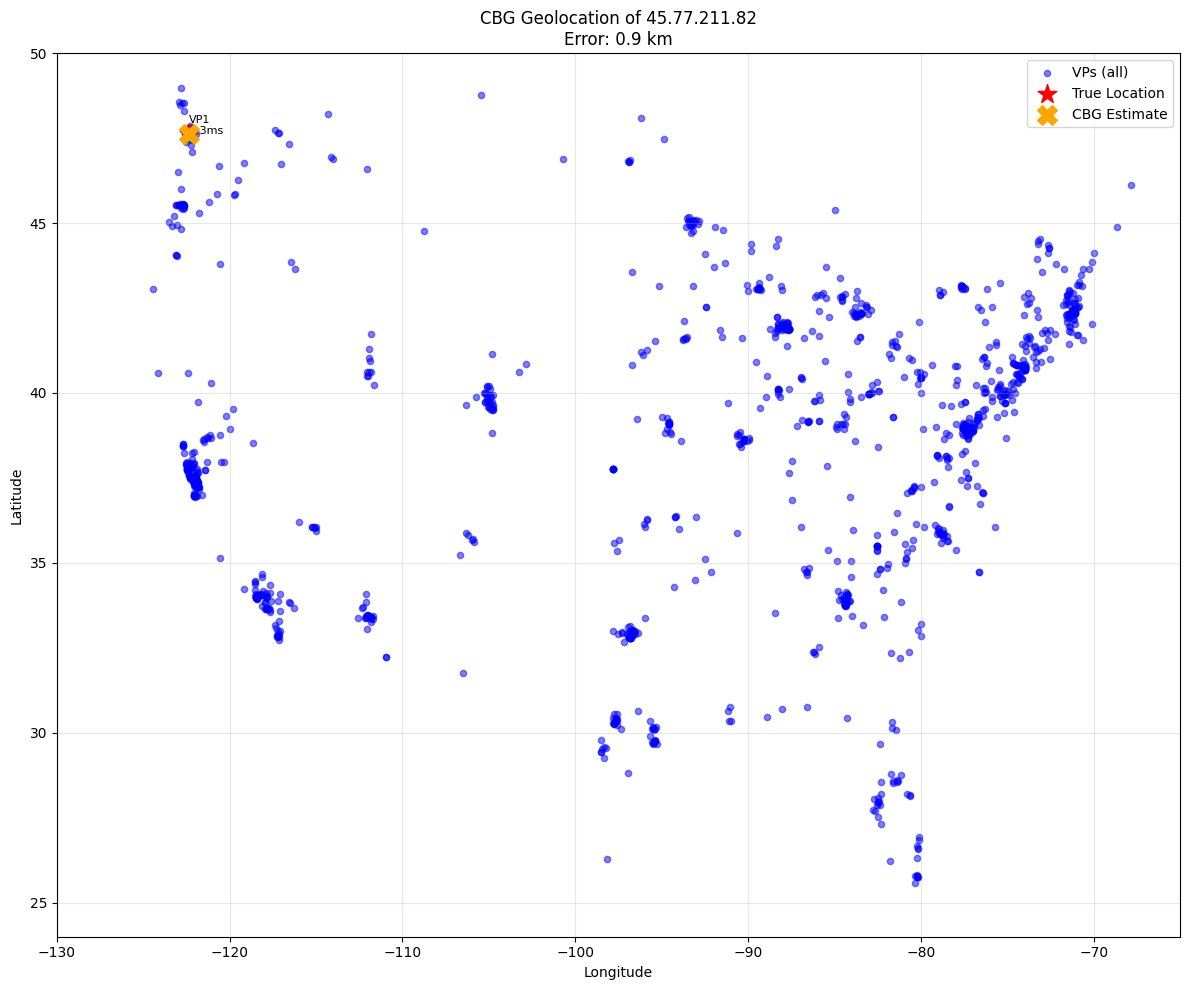

In [17]:
def plot_cbg(measurements_df, true_location, estimated_location, circles, title="CBG Visualization"):
    """
    Visualize the CBG geolocation process.
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # Plot VPs
    ax.scatter(measurements_df['probe_longitude'], measurements_df['probe_latitude'],
               c='blue', s=20, alpha=0.5, label='VPs (all)')
    
    # Plot circles used in CBG
    for i, (lat, lon, rtt, d, r) in enumerate(circles[:5]):  # Show top 5
        # Draw circle
        angles = np.linspace(0, 2*np.pi, 100)
        circle_lats = []
        circle_lons = []
        for angle in angles:
            dx = d * np.cos(angle)
            dy = d * np.sin(angle)
            new_lat = lat + (180/np.pi) * (dy/6378.137)
            new_lon = lon + (180/np.pi) * (dx/6378.137) / np.cos(np.radians(lat))
            circle_lats.append(new_lat)
            circle_lons.append(new_lon)
        
        ax.plot(circle_lons, circle_lats, 'g-', alpha=0.5, linewidth=1)
        ax.scatter([lon], [lat], c='green', s=100, marker='^', zorder=5)
        ax.annotate(f'VP{i+1}\n{rtt:.1f}ms', (lon, lat), fontsize=8)
    
    # Plot true location
    ax.scatter([true_location[1]], [true_location[0]], 
               c='red', s=200, marker='*', label='True Location', zorder=10)
    
    # Plot estimated location
    ax.scatter([estimated_location[1]], [estimated_location[0]], 
               c='orange', s=200, marker='X', label='CBG Estimate', zorder=10)
    
    # Draw line from estimate to true
    ax.plot([estimated_location[1], true_location[1]], 
            [estimated_location[0], true_location[0]], 
            'r--', linewidth=2, alpha=0.7)
    
    error = haversine(estimated_location, true_location)
    ax.set_title(f"{title}\nError: {error:.1f} km")
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Set axis limits to US
    ax.set_xlim(-130, -65)
    ax.set_ylim(24, 50)
    
    plt.tight_layout()
    return fig

# Create visualization
if result:
    fig = plot_cbg(target_data, (true_lat, true_lon), estimated, circles_used,
                   title=f"CBG Geolocation of {target_ip}")
    plt.show()

---
## Step 9: Run CBG on All Targets

Let's geolocate all 7 Vultr anchors in the dataset.

In [18]:
# Get all unique targets
targets = df['dst_ip'].unique()
print(f"Total targets: {len(targets)}")

results = []

for target_ip in targets:
    target_data = df[df['dst_ip'] == target_ip]
    
    # Get true location
    true_lat = target_data['anchor_latitude'].iloc[0]
    true_lon = target_data['anchor_longitude'].iloc[0]
    
    # Run CBG
    result = cbg_geolocate(target_data, n_vps=10, speed_threshold=2/3, verbose=False)
    
    if result:
        estimated, circles_used = result
        error = haversine(estimated, (true_lat, true_lon))
        
        results.append({
            'target_ip': target_ip,
            'true_lat': true_lat,
            'true_lon': true_lon,
            'est_lat': estimated[0],
            'est_lon': estimated[1],
            'error_km': error,
            'n_vps': len(target_data),
            'n_circles': len(circles_used)
        })

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("CBG RESULTS FOR ALL TARGETS")
print("="*80)
print(results_df.to_string(index=False))

print(f"\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"Median error: {results_df['error_km'].median():.1f} km")
print(f"Mean error:   {results_df['error_km'].mean():.1f} km")
print(f"Min error:    {results_df['error_km'].min():.1f} km")
print(f"Max error:    {results_df['error_km'].max():.1f} km")

Total targets: 7
Total intersection points from pairs: 2
Points inside ALL circles: 2
Total intersection points from pairs: 2
Points inside ALL circles: 0
Total intersection points from pairs: 0
Points inside ALL circles: 0
Total intersection points from pairs: 0
Points inside ALL circles: 0
Total intersection points from pairs: 2
Points inside ALL circles: 0

CBG RESULTS FOR ALL TARGETS
     target_ip  true_lat  true_lon  est_lat     est_lon    error_km  n_vps  n_circles
  45.77.211.82   47.6095 -122.3415 47.60950 -122.329500    0.899585   1384          1
  66.42.119.57   41.9905  -87.9585 41.97577  -87.914073    4.020859   1417          2
144.202.18.114   33.7795  -84.4205 33.74850  -84.389500    4.482635   1417          1
149.28.210.233   37.3315 -121.8885 37.75050  -97.822500 2116.509355   1410          3
 149.248.18.65   34.0615 -118.2385 34.05150 -118.238500    1.111949   1414          2
 207.148.2.169   32.7905  -96.7915 32.77950  -96.799500    1.433658   1412          2
207.246

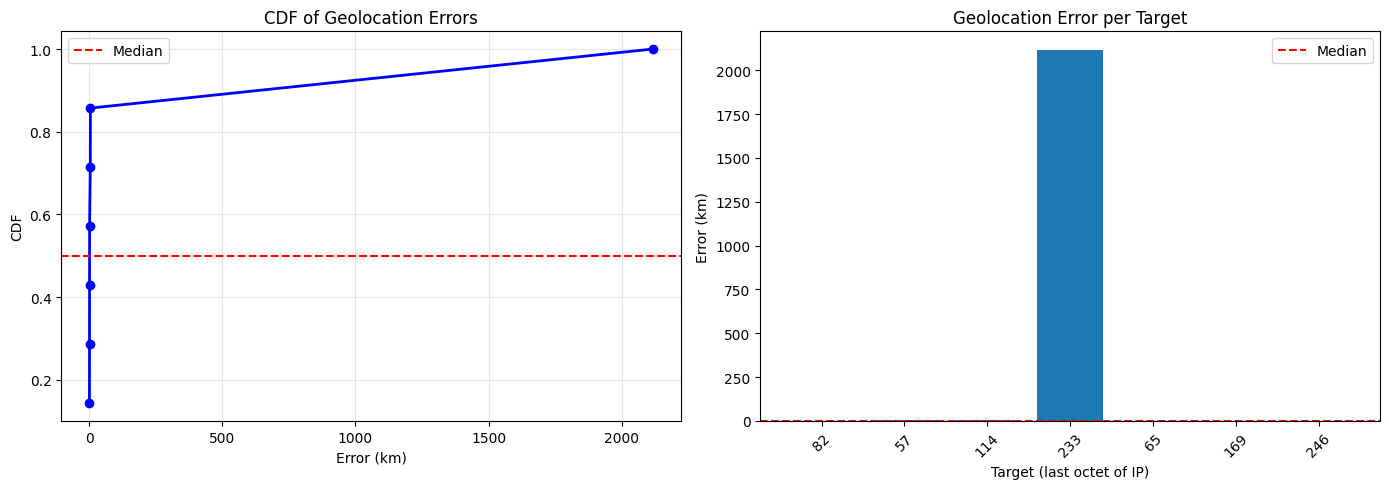

In [19]:
# Plot error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CDF of errors
sorted_errors = np.sort(results_df['error_km'])
cdf = np.arange(1, len(sorted_errors)+1) / len(sorted_errors)
axes[0].plot(sorted_errors, cdf, 'b-', linewidth=2, marker='o')
axes[0].set_xlabel('Error (km)')
axes[0].set_ylabel('CDF')
axes[0].set_title('CDF of Geolocation Errors')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.5, color='r', linestyle='--', label='Median')
axes[0].legend()

# Bar chart of errors per target
axes[1].bar(range(len(results_df)), results_df['error_km'])
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels([ip.split('.')[-1] for ip in results_df['target_ip']], rotation=45)
axes[1].set_xlabel('Target (last octet of IP)')
axes[1].set_ylabel('Error (km)')
axes[1].set_title('Geolocation Error per Target')
axes[1].axhline(y=results_df['error_km'].median(), color='r', linestyle='--', label='Median')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Summary: CBG Algorithm Steps

1. **Collect RTT measurements** from multiple VPs to target
2. **Convert RTT → distance**: `d = (2/3) × c × RTT / 2 = 100 × RTT` (in km)
3. **Create circles**: center = VP location, radius = max distance
4. **Preprocess**: remove circles contained within others
5. **Find intersections**: pairwise circle intersections on sphere
6. **Filter**: keep only points inside ALL circles
7. **Centroid**: average of valid points = estimated location

### Key Parameters
- `n_vps`: Number of VPs to use (more VPs = tighter constraint, but diminishing returns)
- `speed_threshold`: **Fixed at 2/3** in million-scale paper (speed of light in fiber)
- RTT threshold: Skip RTT > 100ms (likely inflated)

### Speed Threshold Note
The million-scale codebase contains a variable speed function with different fractions
based on RTT (1/6, 3/9, 4/9), but **it is NOT used** in the actual analysis.
The code always passes `speed_threshold=2/3`, making the formula simply:

```
max_distance = (2/3) × 300 × RTT / 2 = 100 × RTT (km)
```

### Accuracy Factors
- **VP density** around target: more nearby VPs = better accuracy
- **VP geographic diversity**: VPs from all directions help
- **RTT quality**: lower RTT = smaller circles = tighter constraint